In [1]:
# compare the fits from the default sunkit-spex fit, and my patch for the albedo bumps
# 
# 15-Jul-2026 IGH

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from sunkit_spex.legacy.fitting.fitter import Fitter, load

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

In [3]:
fito=load('fit_saves/sks_stxold.pickle')
fitx=load('fit_saves/sks_stxold_fix.pickle')

In [4]:
oengs=fito.plotting_info['spectrum1']['count_channels']
orat=fito.plotting_info['spectrum1']['count_rates']

oresid=fito.plotting_info['spectrum1']['residuals'][::2]
ofmd=fito.plotting_info['spectrum1']['count_rate_model']
osfmd=fito.plotting_info['spectrum1']['submodels']
ostepe = np.asarray([oengs[i] - oengs[i] for i in range(len(oengs))] + [oengs[-1] + oengs[-1]])
osubsum = np.sum(np.vstack(fito.plotting_info['spectrum1']['submodels']), axis=0)
obkg = fito.plotting_info['spectrum1']['background_rate']
if len(obkg) == 2 * len(ofmd):  # handle step-duplicated background arrays
    obkg = obkg[::2]
ofal = ofmd - osubsum - obkg

In [5]:
xengs=fitx.plotting_info['spectrum1']['count_channels']
xrat=fitx.plotting_info['spectrum1']['count_rates']

xresid=fitx.plotting_info['spectrum1']['residuals'][::2]
xfmd=fitx.plotting_info['spectrum1']['count_rate_model']
xsfmd=fitx.plotting_info['spectrum1']['submodels']
xstepe = np.asarray([xengs[i] - xengs[i] for i in range(len(xengs))] + [xengs[-1] + xengs[-1]])
ns=len(xstepe)
xsubsum = np.sum(np.vstack(fitx.plotting_info['spectrum1']['submodels']), axis=0)
xbkg = fitx.plotting_info['spectrum1']['background_rate']
if len(xbkg) == 2 * len(xfmd):  # handle step-duplicated background arrays
    xbkg = xbkg[::2]
xfal = xfmd - xsubsum - xbkg

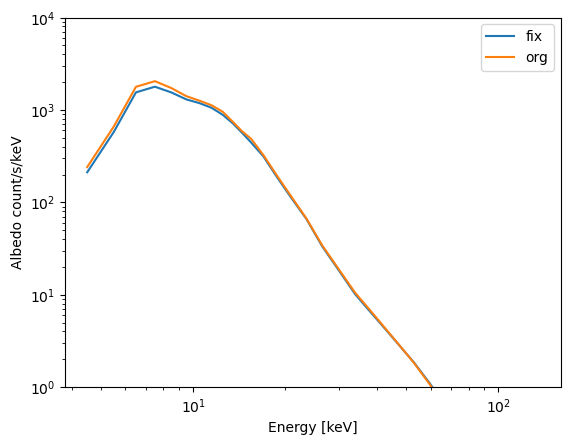

In [6]:
plt.plot(xengs,xfal,label='fix')
plt.plot(oengs,ofal,label='org')
plt.yscale('log')
plt.xscale('log')
plt.ylim([1e0,1e4])
plt.xlabel('Energy [keV]')
plt.ylabel('Albedo count/s/keV')
plt.legend()
plt.show()

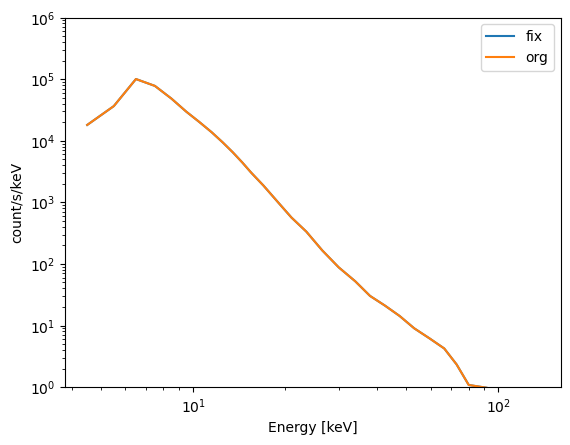

In [7]:
# check the data is the same
plt.plot(xengs,xrat,label='fix')
plt.plot(oengs,orat,label='org')
plt.yscale('log')
plt.xscale('log')
plt.ylim([1e0,1e6])
plt.xlabel('Energy [keV]')
plt.ylabel('count/s/keV')
plt.legend()
plt.show()